<a href="https://colab.research.google.com/github/ejwangombe-create/Titanic-data-analysis-project-/blob/main/Titanic_data_set.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# step 1. import our code
import pandas as pd             # working with data tables
import numpy as np               # working with math and numbers
import matplotlib.pyplot as plt   # for making charts
import seaborn as sns          #for prettier charts
print ("All libraries imported successfully")

All libraries imported successfully


In [ ]:
# step 2. Upload our file and load data set
from google.colab import files
uploaded= files.upload()
df = pd.read_csv('train.csv')
print("Data loaded here are the first 5 rows")
df.head()

Saving train.csv to train.csv
Data loaded here are the first 5 rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
#Fill in missing age with average age
average_age = df['Age'].mean()
df['Age']= df['Age'].fillna (average_age)
print("Average age used:",round(average_age, 1))
print(" Missing ages remaining:" ,df['Age'].isnull().sum())

Average age used: 29.7
 Missing ages remaining: 0


In [ ]:

# Fill missing embarked with most common port
most_common_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_port)

print("Most common port:", most_common_port)
print("Missing embarked remaining:", df['Embarked'].isnull().sum())

Most common port: S
Missing embarked remaining: 0


In [ ]:
# cabin has way to may missing info to be useful drop it
df = df.drop(columns = ['Cabin'])
print ("Cabin column removed ☑️")
print ( " Remaining missing columns:")
print (df.isnull() .sum())

Cabin column removed ☑️
 Remaining missing columns:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
print ( " Data shape now: ", df.shape)
print ( " Total missing values:" , df.isnull().sum().sum())

 Data shape now:  (891, 11)
 Total missing values: 0


In [ ]:
# count how many survived 1= survived 0= deceased
survival_counts = df['Survived'].value_counts()
survival_rate= df ['Survived'].mean()*100
print( survival_counts)
print (f"\nOverall survival rate:{round(survival_rate,1)}%")

Survived
0    549
1    342
Name: count, dtype: int64

Overall survival rate:38.4%


In [ ]:

# Average survival rate by gender
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print("Survival rate by gender:")
print(gender_survival.round(1))

Survival rate by gender:
Sex
female    74.2
male      18.9
Name: Survived, dtype: float64


In [ ]:

# Average survival rate by class (1 = First, 2 = Second, 3 = Third)
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print("Survival rate by passenger class:")
print(class_survival.round(1))

Survival rate by passenger class:
Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64


In [ ]:
# Compare average age of survivors vs non-survivors
age_survival = df.groupby('Survived')['Age'].mean()
print("Average age:")
print(f"Did not survive: {round(age_survival[0], 1)} years")
print(f"Survived: {round(age_survival[1], 1)} years")

Average age:
Did not survive: 30.4 years
Survived: 28.5 years


/tmp/ipykernel_27239/3599500965.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


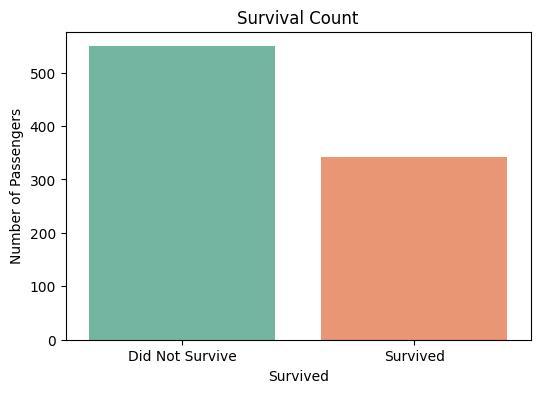

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.title('Survival Count')
plt.ylabel('Number of Passengers')
plt.show()

/tmp/ipykernel_27239/1195905302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')


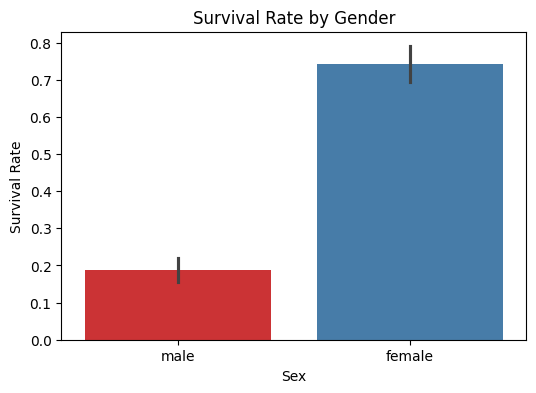

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set1')
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

/tmp/ipykernel_27239/355141279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues')


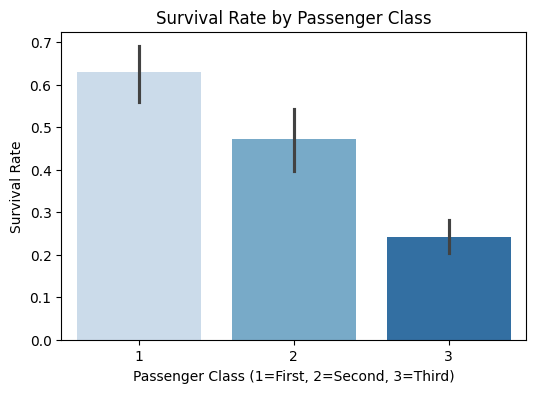

In [ ]:
#Chart 3 — Survival by Class
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df, palette='Blues')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Survival Rate')
plt.show()

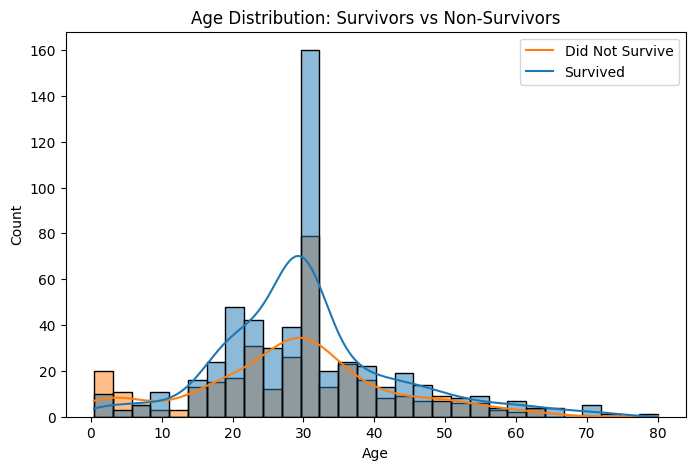

In [ ]:
#Chart 4 — Age Distribution (the one that reveals the hidden pattern!)
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Did Not Survive', 'Survived'])
plt.show()